In [1]:
import pandas as pd

df = pd.read_csv("data/lending_club_preprocessed.csv", parse_dates=['issue_d', 'earliest_cr_line'])


C:\Users\user\AppData\Local\Temp\ipykernel_2412\1692897667.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("data/lending_club_preprocessed.csv", parse_dates=['issue_d', 'earliest_cr_line'])


In [2]:
import numpy as np
import pandas as pd
from scipy.stats import shapiro, levene

def is_categorical(series, unique_threshold=10):
    s = series.dropna()
    if (
        pd.api.types.is_object_dtype(s)
        or isinstance(s.dtype, pd.CategoricalDtype)
        or pd.api.types.is_bool_dtype(s)
    ):
        return True
    if pd.api.types.is_integer_dtype(s) and s.nunique() <= unique_threshold:
        return True
    return False

def check_variable_type_normality_homoscedasticity(
    df: pd.DataFrame,
    target_col: str,
    feature_col: str,
    alpha: float = 0.05
):
    y = df[target_col]
    x = df[feature_col]

    if set(y.dropna().unique()) - {0, 1}:
        raise ValueError(f"{target_col}은 0/1 이진형이어야 합니다.")

    result = {
        "feature": feature_col,
        "feature_type": None,
        "normality_p_y0": np.nan,
        "normality_p_y1": np.nan,
        "normality_ok": None,
        "levene_p": np.nan,
        "equal_variance_ok": None,
        "note": ""
    }

    if is_categorical(x):
        result["feature_type"] = "categorical"
        result["note"] = "범주형 변수는 정규성/등분산성 검정을 하지 않습니다."
        return result

    result["feature_type"] = "continuous"
    g0 = x[y == 0].dropna()
    g1 = x[y == 1].dropna()

    if len(g0) < 3 or len(g1) < 3:
        result["note"] = "각 그룹 표본이 3개 미만이라 정규성/등분산성 검정이 어렵습니다."
        return result

    p0 = shapiro(g0.iloc[:5000]).pvalue
    p1 = shapiro(g1.iloc[:5000]).pvalue
    result["normality_p_y0"] = p0
    result["normality_p_y1"] = p1
    result["normality_ok"] = (p0 >= alpha) and (p1 >= alpha)

    lp = levene(g0, g1).pvalue
    result["levene_p"] = lp
    result["equal_variance_ok"] = (lp >= alpha)

    return result


In [5]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

def mannwhitney_with_effect(df, target_col, feature_col):
    g0 = df.loc[df[target_col] == 0, feature_col].dropna()
    g1 = df.loc[df[target_col] == 1, feature_col].dropna()

    u_stat, p = mannwhitneyu(g0, g1, alternative="two-sided")

    n0, n1 = len(g0), len(g1)
    # rank-biserial correlation (=-1~1, 0이면 효과 거의 없음)
    rbc = (2 * u_stat) / (n0 * n1) - 1
    abs_rbc = abs(rbc)

    # 대략적 해석 기준
    if abs_rbc < 0.1:
        size = "negligible"
    elif abs_rbc < 0.3:
        size = "small"
    elif abs_rbc < 0.5:
        size = "medium"
    else:
        size = "large"

    return {
        "feature": feature_col,
        "test": "Mann-Whitney U",
        "u_stat": u_stat,
        "p_value": p,
        "significant_0.05": p < 0.05,
        "effect_size_rbc": rbc,
        "effect_magnitude": size,
        "median_y0": g0.median(),
        "median_y1": g1.median(),
    }

features = ["num_actv_rev_tl", "mths_since_recent_inq"]
results = [mannwhitney_with_effect(df, "target", f) for f in features]

res = pd.DataFrame(results)

display(
    res.style.format({
        "u_stat": "{:.2f}",
        "p_value": "{:.3e}",          # 예: 1.743e-51
        "effect_size_rbc": "{:.4f}",
        "median_y0": "{:.3f}",
        "median_y1": "{:.3f}",
    })
)



,feature,test,u_stat,p_value,significant_0.05,effect_size_rbc,effect_magnitude,median_y0,median_y1
0,num_actv_rev_tl,Mann-Whitney U,118712124578.00,0.000e+00,True,-0.0983,negligible,5.000,5.000
1,mths_since_recent_inq,Mann-Whitney U,118895369608.00,0.000e+00,True,0.0858,negligible,5.000,4.000


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def plot_normality_by_target(df, target_col, feature_col, bins=30):
    g0 = df.loc[df[target_col] == 0, feature_col].dropna()
    g1 = df.loc[df[target_col] == 1, feature_col].dropna()

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"{feature_col} | Normality Check by {target_col}", fontsize=14)

    # y=0 히스토그램
    sns.histplot(g0, bins=bins, kde=True, ax=axes[0, 0], color="#4C72B0")
    axes[0, 0].set_title(f"Histogram (y=0), n={len(g0)}")

    # y=0 QQ plot
    stats.probplot(g0, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title("QQ Plot (y=0)")

    # y=1 히스토그램
    sns.histplot(g1, bins=bins, kde=True, ax=axes[1, 0], color="#DD8452")
    axes[1, 0].set_title(f"Histogram (y=1), n={len(g1)}")

    # y=1 QQ plot
    stats.probplot(g1, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title("QQ Plot (y=1)")

    plt.tight_layout()
    plt.show()


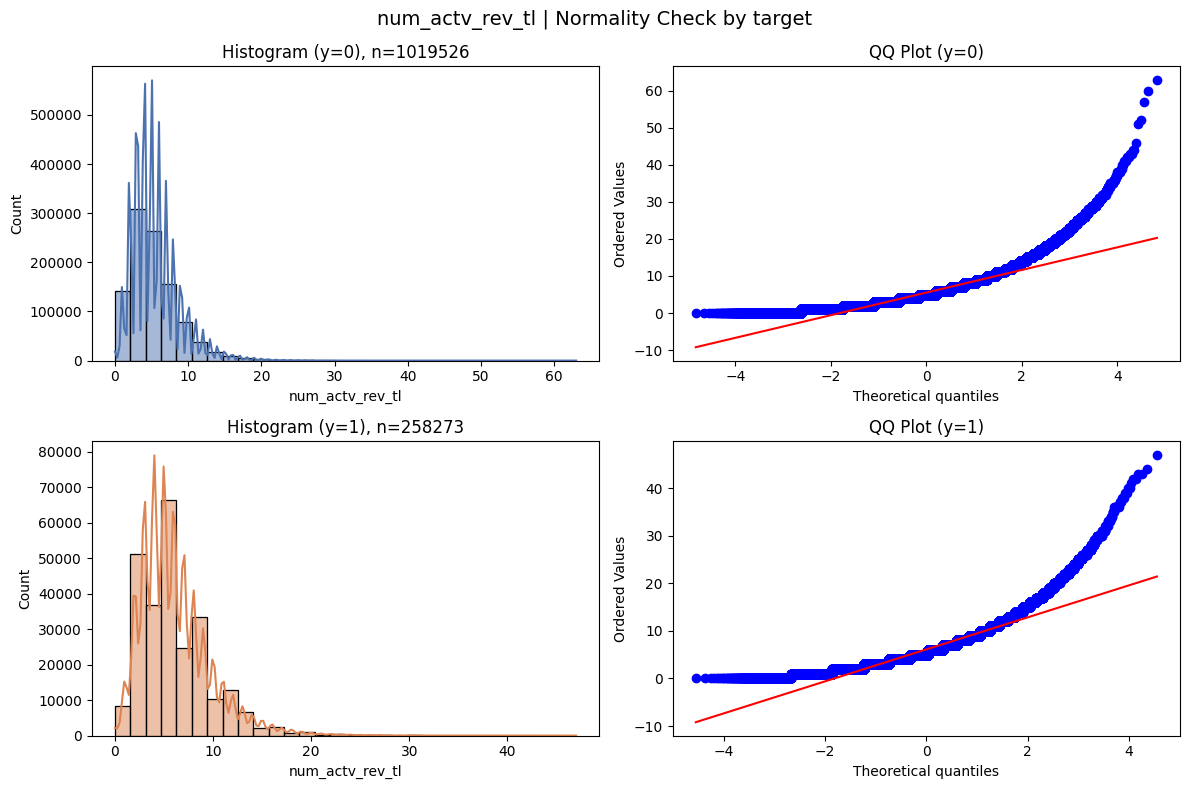

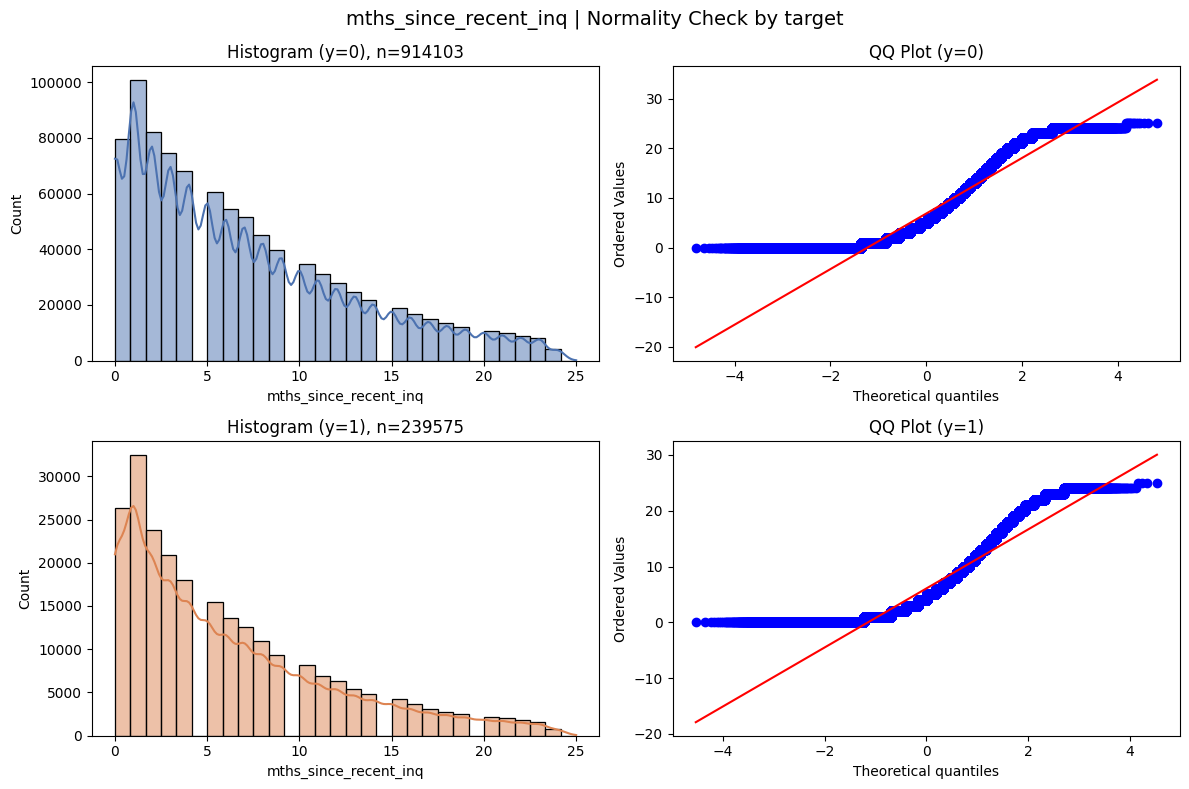

In [7]:
target = "target"
features = ["num_actv_rev_tl", "mths_since_recent_inq"]

for f in features:
    plot_normality_by_target(df, target, f, bins=30)


# 희상님 코드기반

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# -----------------------------
# 1) Mann-Whitney U + 효과크기(rbc)
# -----------------------------
def rank_biserial_from_u(u_stat, n0, n1):
    return 1 - (2 * u_stat) / (n0 * n1)

def effect_label_rbc(abs_rbc):
    if abs_rbc < 0.1:
        return "negligible"
    elif abs_rbc < 0.3:
        return "small"
    elif abs_rbc < 0.5:
        return "medium"
    return "large"

def mannwhitney_table(df, target_col, num_cols):
    rows = []
    for col in num_cols:
        g0 = df.loc[df[target_col] == 0, col].dropna()
        g1 = df.loc[df[target_col] == 1, col].dropna()

        if len(g0) < 3 or len(g1) < 3:
            rows.append({
                "feature": col, "test": "Mann-Whitney U", "u_stat": np.nan, "p_value": np.nan,
                "significant_0.05": np.nan, "effect_size_rbc": np.nan, "effect_magnitude": "insufficient_n",
                "median_y0": g0.median() if len(g0) else np.nan,
                "median_y1": g1.median() if len(g1) else np.nan
            })
            continue

        u_stat, p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
        rbc = rank_biserial_from_u(u_stat, len(g0), len(g1))

        rows.append({
            "feature": col, "test": "Mann-Whitney U", "u_stat": u_stat, "p_value": p,
            "significant_0.05": p < 0.05, "effect_size_rbc": rbc,
            "effect_magnitude": effect_label_rbc(abs(rbc)),
            "median_y0": g0.median(), "median_y1": g1.median()
        })

    # 빈 결과여도 컬럼 유지 (KeyError 방지)
    cols = ["feature", "test", "u_stat", "p_value", "significant_0.05",
            "effect_size_rbc", "effect_magnitude", "median_y0", "median_y1"]
    return pd.DataFrame(rows, columns=cols).sort_values("p_value", na_position="last").reset_index(drop=True)


# -----------------------------
# 2) 카이제곱 + Cramer's V
# -----------------------------
def chi2_cramers_v(df, feature_col, target_col):
    temp = df[[feature_col, target_col]].dropna()
    ct = pd.crosstab(temp[feature_col], temp[target_col])

    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return {"feature": feature_col, "chi2": np.nan, "dof": np.nan, "p_value": np.nan, "cramers_v": np.nan, "note": "insufficient_levels"}

    chi2, p, dof, _ = stats.chi2_contingency(ct)
    n = ct.to_numpy().sum()
    r, c = ct.shape
    denom = n * min(r - 1, c - 1)
    v = np.sqrt(chi2 / denom) if denom > 0 else np.nan

    return {"feature": feature_col, "chi2": chi2, "dof": dof, "p_value": p, "cramers_v": v, "note": ""}

def chi2_table(df, target_col, cat_cols):
    rows = [chi2_cramers_v(df, col, target_col) for col in cat_cols]
    cols = ["feature", "chi2", "dof", "p_value", "cramers_v", "note"]  # 빈 결과여도 컬럼 유지
    return pd.DataFrame(rows, columns=cols).sort_values("p_value", na_position="last").reset_index(drop=True)


# -----------------------------
# 3) 히스토그램 + QQ plot (y=0, y=1)
# -----------------------------
def plot_hist_qq_by_target(df, target_col, feature_col, bins=30):
    g0 = df.loc[df[target_col] == 0, feature_col].dropna()
    g1 = df.loc[df[target_col] == 1, feature_col].dropna()

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"{feature_col} | Histogram + QQ plot", fontsize=14)

    sns.histplot(g0, bins=bins, kde=True, ax=axes[0, 0], color="#4C72B0")
    axes[0, 0].set_title(f"Histogram (y=0), n={len(g0)}")

    stats.probplot(g0, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title("QQ plot (y=0)")

    sns.histplot(g1, bins=bins, kde=True, ax=axes[1, 0], color="#DD8452")
    axes[1, 0].set_title(f"Histogram (y=1), n={len(g1)}")

    stats.probplot(g1, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title("QQ plot (y=1)")

    plt.tight_layout()
    plt.show()


,feature,test,u_stat,p_value,significant_0.05,effect_size_rbc,effect_magnitude,median_y0,median_y1
0,num_actv_rev_tl,Mann-Whitney U,118712124578.00,0.000e+00,True,0.0983,negligible,5.000,5.000
1,mths_since_recent_inq,Mann-Whitney U,118895369608.00,0.000e+00,True,-0.0858,negligible,5.000,4.000


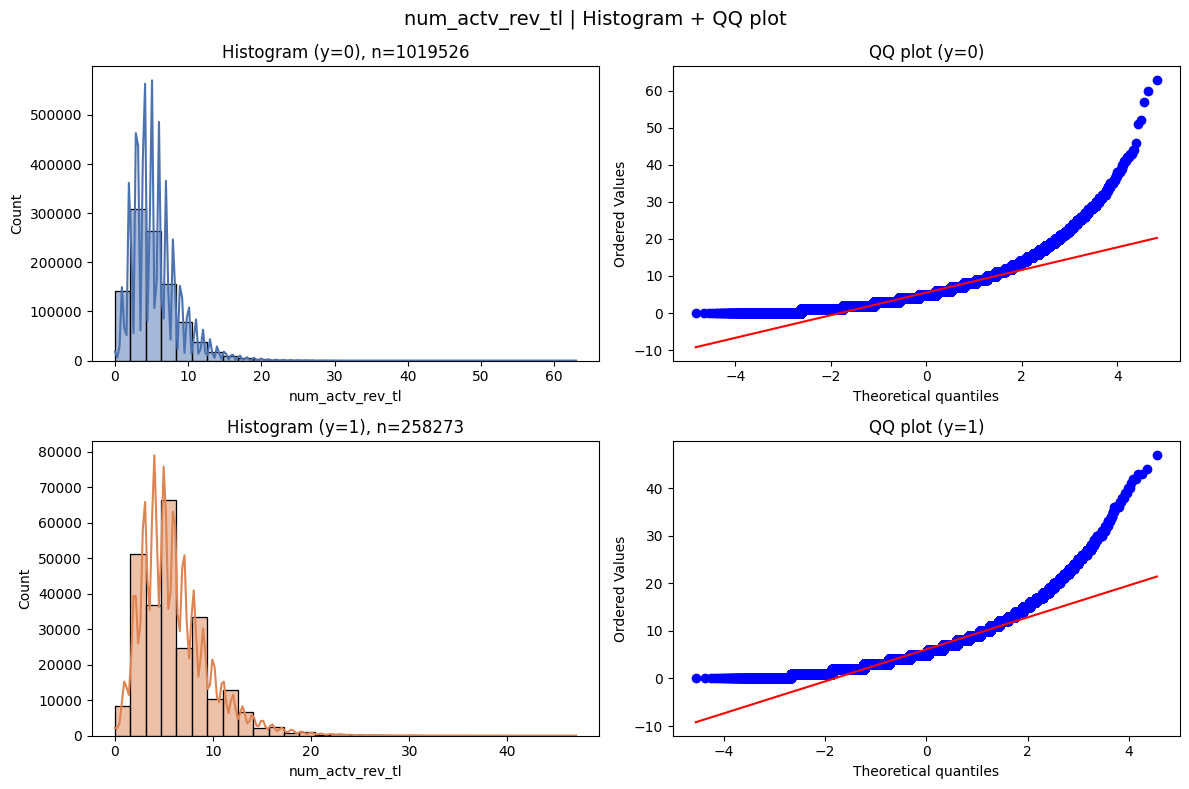

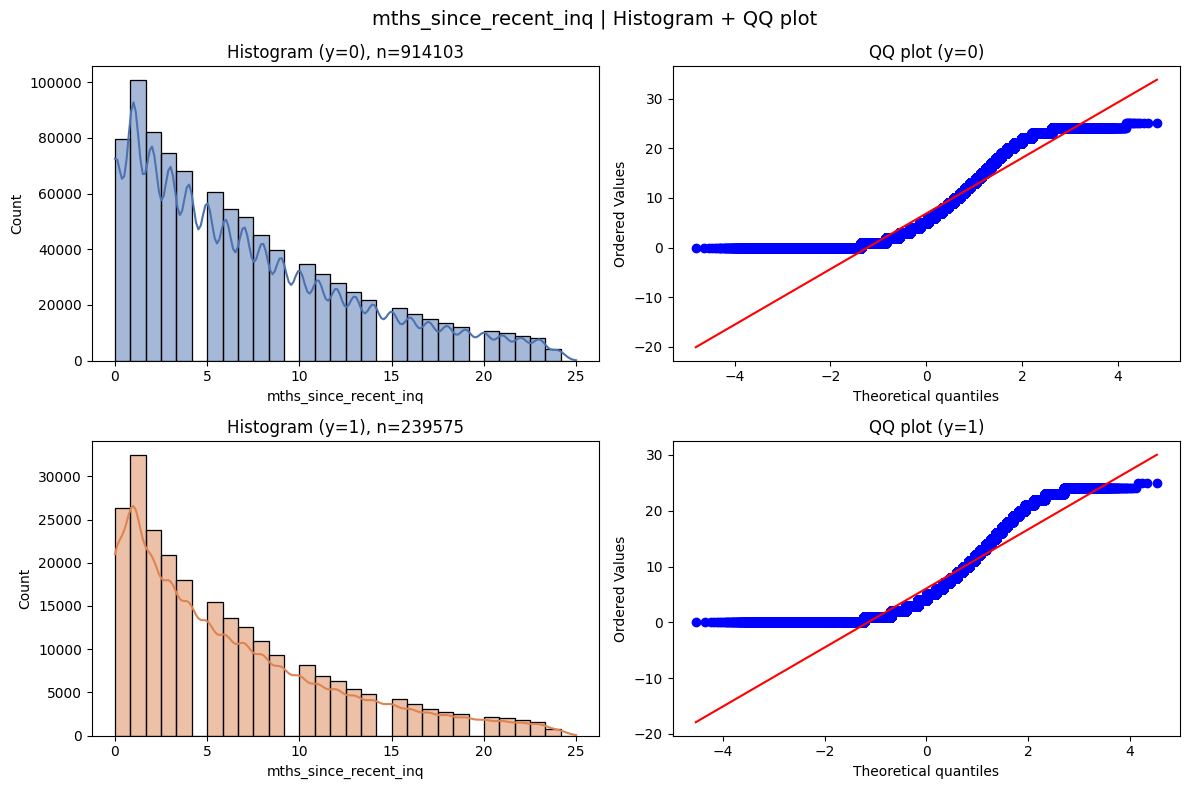

In [12]:
# -----------------------------
# 4) 실행 예시
# -----------------------------
target_col = "target"

target_col = "target"
selected_features = ["num_actv_rev_tl", "mths_since_recent_inq"]

# 1) Mann-Whitney 결과도 두 변수만
mw_res = mannwhitney_table(df, target_col, selected_features)
display(mw_res.style.format({
    "u_stat": "{:.2f}",
    "p_value": "{:.3e}",
    "effect_size_rbc": "{:.4f}",
    "median_y0": "{:.3f}",
    "median_y1": "{:.3f}"
}))

# 2) QQ plot + 히스토그램도 두 변수만
for col in selected_features:
    plot_hist_qq_by_target(df, target_col, col, bins=30)
